---
# **DATA PREPARATION**
---

```text
1. Data Preprocessing
2. Train-Test SPLIT
3. Feature Engineering
4. Imbalance handling
5. Compare models
6. Select a model
7. Train Model
8. Evaluate Model
9. Improve Model
10. Deploy Model
```

<hr>

#### 🧰 INSTALLs


<style>
h1 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: left;
    color: red;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>
<hr>

In [465]:
# install numpy and pandas if not already installed
#!pip install numpy pandas

# install xgboost if not already installed
#!pip install xgboost

# install shap if not already installed
#!pip install shap

# install imbalanced-learn
#!pip install imbalanced-learn

<hr>

#### 📂 IMPORTs


<style>
h1 {
    text-align: center;
    color: black;
    font-weight: bold;
}
</style>

<style>
h2 {
    text-align: left;
    color: red;
    font-weight: bold;
}
</style>

<style>
h3 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>

<style>
h4 {
    text-align: left;
    color: black;
    font-weight: bold;
}
</style>
<hr>

In [466]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import roc_auc_score, f1_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

from xgboost import XGBClassifier

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

---
## **Data Preprocessing**
---

### **Load & View the data**

In this project, we will be working with Online Shoppers Intention UCI Machine Learning. The data can be found here:

https://www.kaggle.com/datasets/henrysue/online-shoppers-intention/data

Metadata



In [467]:
import pandas as pd

# load the clean dataset
df = pd.read_csv("../data/processed/online_shoppers_intention_01_standard.csv")
print("Dataset loaded successfully. Shape:", df.shape)
display(df.head())

Dataset loaded successfully. Shape: (12330, 18)


,admin,admin_duration,info,info_duration,prod_related,prod_related_duration,bounce_rate,exit_rate,page_value,special_day,month,os,browser,region,traffic_type,visitor_type,weekend,revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [468]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   admin                  12330 non-null  int64  
 1   admin_duration         12330 non-null  float64
 2   info                   12330 non-null  int64  
 3   info_duration          12330 non-null  float64
 4   prod_related           12330 non-null  int64  
 5   prod_related_duration  12330 non-null  float64
 6   bounce_rate            12330 non-null  float64
 7   exit_rate              12330 non-null  float64
 8   page_value             12330 non-null  float64
 9   special_day            12330 non-null  float64
 10  month                  12330 non-null  str    
 11  os                     12330 non-null  int64  
 12  browser                12330 non-null  int64  
 13  region                 12330 non-null  int64  
 14  traffic_type           12330 non-null  int64  
 15  visitor_type 

None

### **Check shape**

In [469]:
print("Shape:", df.shape[0], "rows and", df.shape[1], "columns\n")

Shape: 12330 rows and 18 columns



### **Check data types**

In [470]:
print("Data Types:")
df.dtypes

Data Types:


admin                      int64
admin_duration           float64
info                       int64
info_duration            float64
prod_related               int64
prod_related_duration    float64
bounce_rate              float64
exit_rate                float64
page_value               float64
special_day              float64
month                        str
os                         int64
browser                    int64
region                     int64
traffic_type               int64
visitor_type                 str
weekend                     bool
revenue                     bool
dtype: object

### **Check missing values**

There are multiple strategies to handle missing data
- Removing all rows or all columns containing missing data.
- Filling all missing values with a value (mean in continouos or mode in categorical for example).
- Filling all missing values with an algorithm.

In [471]:
print("Missing Values:")
print(df.isna().sum())
print(df.info())

Missing Values:
admin                    0
admin_duration           0
info                     0
info_duration            0
prod_related             0
prod_related_duration    0
bounce_rate              0
exit_rate                0
page_value               0
special_day              0
month                    0
os                       0
browser                  0
region                   0
traffic_type             0
visitor_type             0
weekend                  0
revenue                  0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   admin                  12330 non-null  int64  
 1   admin_duration         12330 non-null  float64
 2   info                   12330 non-null  int64  
 3   info_duration          12330 non-null  float64
 4   prod_related           12330 non-null  int64  
 5   prod_related_durat

In [472]:
# Loop print unique values of each column
for col in df.columns:
    unique_vals = df[col].unique()
    print(f"Column: {col}")
    print(f"Unique values ({len(unique_vals)}): {unique_vals}\n")


Column: admin
Unique values (27): [ 0  1  2  4 12  3 10  6  5  9  8 16 13 11  7 18 14 17 19 15 24 22 21 20
 23 27 26]

Column: admin_duration
Unique values (3335): [  0.         53.         64.6       ... 167.9107143 305.125
 150.3571429]

Column: info
Unique values (17): [ 0  1  2  4 16  5  3 14  6 12  7  9 10  8 11 24 13]

Column: info_duration
Unique values (1258): [  0.   120.    16.   ... 547.75 368.25 211.25]

Column: prod_related
Unique values (311): [  1   2  10  19   0   3  16   7   6  23  13  20   8   5  32   4  45  14
  52   9  46  15  22  11  12  36  42  27  90  18  38  17 128  25  30  21
  51  26  28  31  24  50  96  49  68  98  67  55  35  37  29  34  71  63
  87  40  33  54  64  75  39 111  81  61  47  44  88 149  41  79  66  43
 258  80  62  83 173  48  58  57  56  69  82  59 109 287  53  84  78 137
 113  89  65  60 104 129  77  74  93  76  72 194 140 110 132 115  73 328
 160  86 150  95 130 151 117 124 127 125 116 105  92 157 154 220 187 112
 131 159  94 204 142 206 10

In [473]:
# loop through columns and print sum of nulls for each column
for col in df.columns:
    print(f"Null values in '{col}': [{df[col].isna().sum()}]")

Null values in 'admin': [0]
Null values in 'admin_duration': [0]
Null values in 'info': [0]
Null values in 'info_duration': [0]
Null values in 'prod_related': [0]
Null values in 'prod_related_duration': [0]
Null values in 'bounce_rate': [0]
Null values in 'exit_rate': [0]
Null values in 'page_value': [0]
Null values in 'special_day': [0]
Null values in 'month': [0]
Null values in 'os': [0]
Null values in 'browser': [0]
Null values in 'region': [0]
Null values in 'traffic_type': [0]
Null values in 'visitor_type': [0]
Null values in 'weekend': [0]
Null values in 'revenue': [0]


### **Check duplicates**

In [474]:
# print number of duplicated rows
num_duplicates = df.duplicated().sum()
print(f"Number of duplicated rows: {num_duplicates}")

Number of duplicated rows: 125


### **Leakage Handling**
**DROP**
- identifier column (Id) and (Name), they are not useful features (high cardinality and not predictive)
- columns that are future information

Data leakage happens when:
- Information from the test set influences training
- Or when a feature contains **future information**
- Or when preprocessing is done **before splitting**

Very important:
- Remove post-event features
- Remove target proxies
- Remove ID-like features
- Check correlation with target
- Drop leakage features  
- Ensure no post-target info (variables) exists
- Fit transformations only on training set

Note:
- This step is more important than imbalance handling
- This step can be done either before or right after the step 2 - train/test split

### **Deal with IDs & Name Columns**

In [475]:
# df = df.drop(["IDs", "Name",...], axis=1)

### **Deal with Nulls & Duplicates**

In [476]:
# remove nulls
# df = df.dropna()

# remove duplicates
# df = df.drop_duplicates()


### **Convert Data TYPE**

In [477]:
# --- Convert Boolean to integer ---
# boolean columns
bool_cols = ["weekend", "revenue"]

# convert booleans to integers (True=1, False=0) for better modeling
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

---
### **CHECK PREPROCESSED DATA**

In [478]:
# display cleaned dataframe
display(df.head())

,admin,admin_duration,info,info_duration,prod_related,prod_related_duration,bounce_rate,exit_rate,page_value,special_day,month,os,browser,region,traffic_type,visitor_type,weekend,revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,0,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,0,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,0,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,0,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,1,0


| Variable                  | Cat vs Num   | Identity | Original Python Type | Action          | Convert to | Definition |
|---------------------------|-------------|----------|----------------------|-----------------|------------|------------|
| `admin`                   | Numerical   | Feature  | int                  | Scale           | -          | Number of pages visited by the visitor in the Administrative category |
| `admin_duration`          | Numerical   | Feature  | float                | Scale           | -          | Total time (in seconds) spent on Administrative pages |
| `info`                    | Numerical   | Feature  | int                  | Scale           | -          | Number of pages visited in the Informational category |
| `info_duration`           | Numerical   | Feature  | float                | Scale           | -          | Total time (in seconds) spent on Informational pages |
| `prod_related`            | Numerical   | Feature  | int                  | Scale           | -          | Number of pages visited in the Product-Related category |
| `prod_related_duration`   | Numerical   | Feature  | float                | Scale           | -          | Total time (in seconds) spent on Product-Related pages |
| `bounce_rate`             | Numerical   | Feature  | float                | Scale           | -          | Average bounce rate of the pages visited (percentage of single-page sessions) |
| `exit_rate`               | Numerical   | Feature  | float                | Scale           | -          | Average exit rate of the pages visited (percentage of exits from those pages) |
| `page_value`              | Numerical   | Feature  | float                | Scale           | -          | Average value of the pages visited before completing a transaction (estimated by Google Analytics) |
| `special_day`             | Numerical   | Feature  | float                | Scale           | -          | Closeness of the visit date to a specific special shopping day (value between 0 and 1) |
| `month`                   | Categorical | Feature  | str                  | One-Hot Encode  | int        | Month of the session (e.g., Feb, Mar, May, Nov, Dec) |
| `os`                      | Categorical | Feature  | int                  | One-Hot Encode  | -          | Operating system of the visitor (encoded categorical identifier) |
| `browser`                 | Categorical | Feature  | int                  | One-Hot Encode  | -          | Web browser used by the visitor (encoded categorical identifier) |
| `region`                  | Categorical | Feature  | int                  | One-Hot Encode  | -          | Geographic region of the visitor (encoded categorical identifier) |
| `traffic_type`            | Categorical | Feature  | int                  | One-Hot Encode  | -          | Traffic source type (encoded categorical identifier) |
| `visitor_type`            | Categorical | Feature  | str                  | One-Hot Encode  | int        | Visitor type (Returning Visitor, New Visitor, or Other) |
| `weekend`                 | Categorical | Feature  | bool                 | -               | int        | Whether the session occurred on a weekend (TRUE/FALSE) |
| `revenue`                 | Categorical | Target   | bool                 | -               | int        | Whether the session ended with a completed transaction (TRUE/FALSE) |

In [479]:
# display info cleaned dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   admin                  12330 non-null  int64  
 1   admin_duration         12330 non-null  float64
 2   info                   12330 non-null  int64  
 3   info_duration          12330 non-null  float64
 4   prod_related           12330 non-null  int64  
 5   prod_related_duration  12330 non-null  float64
 6   bounce_rate            12330 non-null  float64
 7   exit_rate              12330 non-null  float64
 8   page_value             12330 non-null  float64
 9   special_day            12330 non-null  float64
 10  month                  12330 non-null  str    
 11  os                     12330 non-null  int64  
 12  browser                12330 non-null  int64  
 13  region                 12330 non-null  int64  
 14  traffic_type           12330 non-null  int64  
 15  visitor_type 

In [480]:
# loop print unique values for each column
for col in df.columns:
        print(f"['{col}]': {df[col].unique()}")

['admin]': [ 0  1  2  4 12  3 10  6  5  9  8 16 13 11  7 18 14 17 19 15 24 22 21 20
 23 27 26]
['admin_duration]': [  0.         53.         64.6       ... 167.9107143 305.125
 150.3571429]
['info]': [ 0  1  2  4 16  5  3 14  6 12  7  9 10  8 11 24 13]
['info_duration]': [  0.   120.    16.   ... 547.75 368.25 211.25]
['prod_related]': [  1   2  10  19   0   3  16   7   6  23  13  20   8   5  32   4  45  14
  52   9  46  15  22  11  12  36  42  27  90  18  38  17 128  25  30  21
  51  26  28  31  24  50  96  49  68  98  67  55  35  37  29  34  71  63
  87  40  33  54  64  75  39 111  81  61  47  44  88 149  41  79  66  43
 258  80  62  83 173  48  58  57  56  69  82  59 109 287  53  84  78 137
 113  89  65  60 104 129  77  74  93  76  72 194 140 110 132 115  73 328
 160  86 150  95 130 151 117 124 127 125 116 105  92 157 154 220 187 112
 131 159  94 204 142 206 102 313 145  85  97 198 181 126 106 101 108 119
  70 122  91 276 100 291 114 172 217 141 133 156 136 180 135 195  99 362
 179 

---
## **Train / Validation / Test Split**

Now that we have split the data into **features** and **target** variables and imported the **train_test_split** function, split X and y into X_train, X_test, y_train, and y_test. 80% of the data should be in the training set and 20% in the test set.

### **Define target (y)**

In [481]:
# define target variable
y = df["revenue"]

### **Define features (X)**
```text
X = df.drop("revenue", axis=1)  # features without the target variable "revenue"
y = df["revenue"]               # target variable "revenue"
```

In [482]:
# define features
X = df.drop(["revenue"], axis=1)

### **Split: Train / Validation / Test (Stratified)**
Use `random_state=42` , `stratify`

Use:
- Train → fitting
- Validation → early stopping + hyperparameter tuning
- Test → final evaluation only once

In [483]:
from sklearn.model_selection import train_test_split

# First split (70% train, 30% temp)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Second split (15% val, 15% test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (8631, 17)
Validation: (1849, 17)
Test: (1850, 17)


**Check split data**

In [484]:
print(f"Features=(X) and target=(y) separated. \nShapes:\nX =", X.shape, ", y =", y.shape)
print(100*"-")
print(f"Train/Test split completed. \nShapes: \nX_train = {X_train.shape}, y_train = {y_train.shape}, \nX_test = {X_test.shape}, y_test = {y_test.shape}")
print(100*"-")
print("Display X_train:")
display(X_train.head())

Features=(X) and target=(y) separated. 
Shapes:
X = (12330, 17) , y = (12330,)
----------------------------------------------------------------------------------------------------
Train/Test split completed. 
Shapes: 
X_train = (8631, 17), y_train = (8631,), 
X_test = (1850, 17), y_test = (1850,)
----------------------------------------------------------------------------------------------------
Display X_train:


,admin,admin_duration,info,info_duration,prod_related,prod_related_duration,bounce_rate,exit_rate,page_value,special_day,month,os,browser,region,traffic_type,visitor_type,weekend
7460,4,45.40,0,0.0,14,339.000000,0.000000,0.010526,0.0,0.0,Jul,2,2,1,5,New_Visitor,0
4687,1,40.25,0,0.0,19,501.766667,0.000000,0.010526,0.0,0.0,May,2,2,1,4,Returning_Visitor,0
790,0,0.00,0,0.0,13,244.166667,0.000000,0.030769,0.0,0.0,Mar,2,5,3,3,Returning_Visitor,0
9057,6,62.75,0,0.0,46,1098.524802,0.007083,0.016530,0.0,0.0,Nov,1,1,4,8,Returning_Visitor,0
225,0,0.00,0,0.0,2,19.000000,0.000000,0.100000,0.0,0.0,Mar,2,2,3,11,Returning_Visitor,1


---
## **Feautres Engineering**

Steps to Features Engineering:

1. Identify Categorical vs Numerical Features

2. Encode Categorical Features & Scale Numerical Features
- Categorical Features:
    - Hot-one encoding for seperate categories
    - Labeling for ordinal variables
- Numerical Features:
    - Scaling because models can be sensitive to big numbers

3. Convert Target to numeric python type int (False=0; True=1) //Can also be done in the data prep
4. Convert all Features to numeric python type int or float //Can also be done in the data prep
5. Save `X_train.csv`,`X_test.csv` and `y_train.csv`,`y_test.csv`

### **1. Identify Categorical vs Numerical Features**

In [485]:
# define categorical features
cat_cols = ["month", "os", "browser", "region", "traffic_type", "visitor_type"]
        
# define numerical features
num_cols = [col for col in X.columns if col not in cat_cols]

### **2. Encoding Cat & Scaling Num Features**

**All Models require Encoding Categorical Features** 
- OneHotEncoder (nominal)
- OrdinalEncoder (ordinal)
- Handle unknown categories when Encoding
- Avoid label encoding for nominal variables

**Scaling can be conditional per model:**
- **Models that require Scaling:** 
    - Linear models (Logistic Regression, Ridge, Lasso, ElasticNet)
    - Support Vector Machines (SVM)
    - K-Nearest Neighbors (KNN)
    - Neural Networks
    - K-Means / distance-based algorithms

- **Models that DON'T require Scaling:** 
    - Tree-based models (Decision Trees, Random Forest, XGBoost, LightGBM, CatBoost)



In [486]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, RobustScaler

# ===============================
# ---- One-Hot Encode ----
# ===============================

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Fit ONLY on training categorical data
X_train_cat = pd.DataFrame(
    ohe.fit_transform(X_train[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_train.index
)

# Transform validation
X_val_cat = pd.DataFrame(
    ohe.transform(X_val[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_val.index
)

# Transform test
X_test_cat = pd.DataFrame(
    ohe.transform(X_test[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_test.index
)

# ===============================
# ---- Scale Numerical ----
# ===============================

scaler = RobustScaler()

# Fit ONLY on training numerical data
X_train_num = pd.DataFrame(
    scaler.fit_transform(X_train[num_cols]),
    columns=num_cols,
    index=X_train.index
)

# Transform validation
X_val_num = pd.DataFrame(
    scaler.transform(X_val[num_cols]),
    columns=num_cols,
    index=X_val.index
)

# Transform test
X_test_num = pd.DataFrame(
    scaler.transform(X_test[num_cols]),
    columns=num_cols,
    index=X_test.index
)

# ===============================
# ---- Concatenate Back ----
# ===============================

X_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_val   = pd.concat([X_val_num,   X_val_cat], axis=1)
X_test  = pd.concat([X_test_num,  X_test_cat], axis=1)

# ===============================
# ---- Display Shapes ----
# ===============================

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)


display(X_train.head())

# save processed data
X_train.to_csv("X_train.csv", index=False)
X_val.to_csv("X_val.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_val.to_csv("y_val.csv", index=False)
y_test.to_csv("y_test.csv", index=False)


X_train shape: (8631, 74)
X_val shape: (1849, 74)
X_test shape: (1850, 74)
y_train shape: (8631,)
y_val shape: (1849,)
y_test shape: (1850,)


,admin,admin_duration,info,info_duration,prod_related,prod_related_duration,bounce_rate,exit_rate,page_value,special_day,weekend,month_Aug,month_Dec,month_Feb,month_Jul,month_June,month_Mar,month_May,month_Nov,month_Oct,month_Sep,os_1,os_2,os_3,os_4,os_5,os_6,os_7,os_8,browser_1,browser_2,browser_3,browser_4,browser_5,browser_6,browser_7,browser_8,browser_9,browser_10,browser_11,browser_12,browser_13,region_1,region_2,region_3,region_4,region_5,region_6,region_7,region_8,region_9,traffic_type_1,traffic_type_2,traffic_type_3,traffic_type_4,traffic_type_5,traffic_type_6,traffic_type_7,traffic_type_8,traffic_type_9,traffic_type_10,traffic_type_11,traffic_type_12,traffic_type_13,traffic_type_14,traffic_type_15,traffic_type_16,traffic_type_17,traffic_type_18,traffic_type_19,traffic_type_20,visitor_type_New_Visitor,visitor_type_Other,visitor_type_Returning_Visitor
7460,0.75,0.403235,0.0,0.0,-0.133333,-0.200965,-0.173913,-0.405602,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4687,0.00,0.347709,0.0,0.0,0.033333,-0.073728,-0.173913,-0.405602,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
790,-0.25,-0.086253,0.0,0.0,-0.166667,-0.275097,-0.173913,0.161199,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9057,1.25,0.590296,0.0,0.0,0.933333,0.392764,0.251087,-0.237503,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
225,-0.25,-0.086253,0.0,0.0,-0.533333,-0.451112,-0.173913,2.099661,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [487]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 8631 entries, 7460 to 11106
Data columns (total 74 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   admin                           8631 non-null   float64
 1   admin_duration                  8631 non-null   float64
 2   info                            8631 non-null   float64
 3   info_duration                   8631 non-null   float64
 4   prod_related                    8631 non-null   float64
 5   prod_related_duration           8631 non-null   float64
 6   bounce_rate                     8631 non-null   float64
 7   exit_rate                       8631 non-null   float64
 8   page_value                      8631 non-null   float64
 9   special_day                     8631 non-null   float64
 10  weekend                         8631 non-null   float64
 11  month_Aug                       8631 non-null   float64
 12  month_Dec                       8631 non-null 

---
# **BASELINE MODEL (XGBoost)**

**IMPORTs**

In [488]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    precision_recall_curve
)
from xgboost import XGBClassifier
import numpy as np
import pandas as pd

### **Load Train, Validation, Test sets from CSVs**

In [489]:
import pandas as pd

X_train = pd.read_csv("X_train.csv")
X_val = pd.read_csv("X_val.csv")
X_test = pd.read_csv("X_test.csv")

y_train = pd.read_csv("y_train.csv")
y_val = pd.read_csv("y_val.csv")
y_test = pd.read_csv("y_test.csv")

**SANITY CHECK**

In [490]:
# sanity check - check class distribution in target variable
print("Train sets shapes:", X_train.shape, y_train.shape)
print("Train class distribution:")
print(y_train.value_counts(), y_train.value_counts(normalize=True).round(2))
print(100*"-")
print("Test set shapes:", X_test.shape, y_test.shape)
print("Test class distribution:")
print(y_test.value_counts(), y_test.value_counts(normalize=True).round(2))

Train sets shapes: (8631, 74) (8631, 1)
Train class distribution:
revenue
0          7295
1          1336
Name: count, dtype: int64 revenue
0          0.85
1          0.15
Name: proportion, dtype: float64
----------------------------------------------------------------------------------------------------
Test set shapes: (1850, 74) (1850, 1)
Test class distribution:
revenue
0          1564
1           286
Name: count, dtype: int64 revenue
0          0.85
1          0.15
Name: proportion, dtype: float64


In [491]:
y_train = pd.read_csv("y_train.csv").squeeze()
y_val   = pd.read_csv("y_val.csv").squeeze()
y_test  = pd.read_csv("y_test.csv").squeeze()

### Compute Class Imbalance Weight

In [492]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
scale_pos_weight = float(scale_pos_weight)

print(scale_pos_weight)
print(type(scale_pos_weight))

5.460329341317365
<class 'float'>


### **Define & Train Baseline Model**

**Purpose** →  Train the selected algorithm on the training data to learn patterns and relationships between features and the target variable. 

In [493]:
from xgboost import XGBClassifier

# define Baseline - XGBoost model
model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='aucpr',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=6,
    early_stopping_rounds=50
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=True
)

[0]	validation_0-aucpr:0.66599
[1]	validation_0-aucpr:0.66196
[2]	validation_0-aucpr:0.65863
[3]	validation_0-aucpr:0.65962
[4]	validation_0-aucpr:0.67413
[5]	validation_0-aucpr:0.67391
[6]	validation_0-aucpr:0.67468
[7]	validation_0-aucpr:0.67427
[8]	validation_0-aucpr:0.67262
[9]	validation_0-aucpr:0.67231
[10]	validation_0-aucpr:0.68051
[11]	validation_0-aucpr:0.68129
[12]	validation_0-aucpr:0.68162
[13]	validation_0-aucpr:0.68061
[14]	validation_0-aucpr:0.68133
[15]	validation_0-aucpr:0.68027
[16]	validation_0-aucpr:0.68321
[17]	validation_0-aucpr:0.68409
[18]	validation_0-aucpr:0.68330
[19]	validation_0-aucpr:0.68386
[20]	validation_0-aucpr:0.68760
[21]	validation_0-aucpr:0.68834
[22]	validation_0-aucpr:0.68783
[23]	validation_0-aucpr:0.69212
[24]	validation_0-aucpr:0.69191
[25]	validation_0-aucpr:0.69448
[26]	validation_0-aucpr:0.69548
[27]	validation_0-aucpr:0.69525
[28]	validation_0-aucpr:0.69571
[29]	validation_0-aucpr:0.69779
[30]	validation_0-aucpr:0.69894
[31]	validation_0-

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

### **Evaluate Baseline Model**

❗ What You Do NOT Do Yet

🚫 Do NOT evaluate on test
🚫 Do NOT tune threshold yet
🚫 Do NOT tune hyperparameters yet

Evaluate on Validation Set (NOT Test Yet)

Validation PR-AUC: 0.7045052491700979
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      1563
           1       0.53      0.77      0.62       286

    accuracy                           0.86      1849
   macro avg       0.74      0.82      0.77      1849
weighted avg       0.89      0.86      0.87      1849

Confusion Matrix:
[[1367  196]
 [  67  219]]


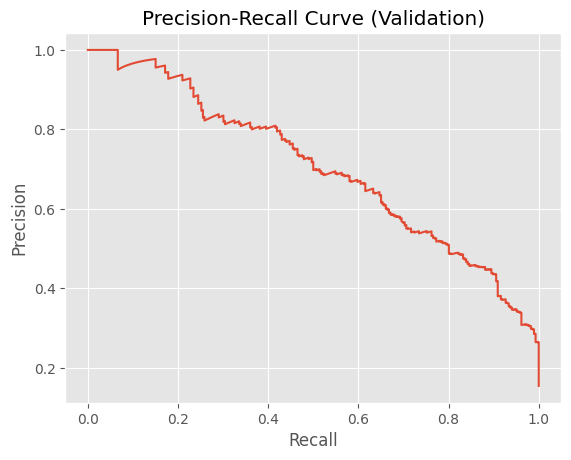

In [494]:
from sklearn.metrics import average_precision_score
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Predict Probabilities
y_val_proba = model.predict_proba(X_val)[:, 1]

# PR-AUC (Main Metric)
pr_auc = average_precision_score(y_val, y_val_proba)
print("Validation PR-AUC:", pr_auc)



# Classification Metrics (Default Threshold = 0.5)

y_val_pred = (y_val_proba >= 0.5).astype(int)

print("Classification Report:")
print(classification_report(y_val, y_val_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))


# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_val, y_val_proba)
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Validation)")
plt.show()

# Hyperparameter Tuning 

(Using Train + Validation Properly)

We will:
- Tune using train set
- Use validation set for early stopping
- Optimize for PR-AUC
- Keep test set untouched

#### STEP 1 — Define Parameter Search Space
These are the most important parameters for controlling overfitting:

In [495]:
param_grid = {
    "max_depth": [3, 4, 5, 6],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 5, 10],
    "learning_rate": [0.01, 0.05, 0.1]
}

#### STEP 2 — Manual Random Search with Early Stopping

In [496]:
import random
from sklearn.metrics import average_precision_score
from xgboost import XGBClassifier

best_score = 0
best_params = None

n_trials = 30

for i in range(n_trials):
    
    params = {
        "max_depth": random.choice(param_grid["max_depth"]),
        "min_child_weight": random.choice(param_grid["min_child_weight"]),
        "gamma": random.choice(param_grid["gamma"]),
        "subsample": random.choice(param_grid["subsample"]),
        "colsample_bytree": random.choice(param_grid["colsample_bytree"]),
        "reg_alpha": random.choice(param_grid["reg_alpha"]),
        "reg_lambda": random.choice(param_grid["reg_lambda"]),
        "learning_rate": random.choice(param_grid["learning_rate"]),
    }

    model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='aucpr',
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_estimators=1000,
        early_stopping_rounds=50,   
        **params
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False               
    )

    y_val_proba = model.predict_proba(X_val)[:, 1]
    score = average_precision_score(y_val, y_val_proba)

    print(f"Trial {i+1} | PR-AUC: {score:.4f}")

    if score > best_score:
        best_score = score
        best_params = params

print("\nBest PR-AUC:", best_score)
print("Best Parameters:", best_params)

Trial 1 | PR-AUC: 0.6389
Trial 2 | PR-AUC: 0.7274
Trial 3 | PR-AUC: 0.7240
Trial 4 | PR-AUC: 0.7207
Trial 5 | PR-AUC: 0.7297
Trial 6 | PR-AUC: 0.7294
Trial 7 | PR-AUC: 0.6643
Trial 8 | PR-AUC: 0.7236
Trial 9 | PR-AUC: 0.7322
Trial 10 | PR-AUC: 0.6542
Trial 11 | PR-AUC: 0.7000
Trial 12 | PR-AUC: 0.7265
Trial 13 | PR-AUC: 0.7308
Trial 14 | PR-AUC: 0.7289
Trial 15 | PR-AUC: 0.7171
Trial 16 | PR-AUC: 0.6201
Trial 17 | PR-AUC: 0.7298
Trial 18 | PR-AUC: 0.7368
Trial 19 | PR-AUC: 0.7266
Trial 20 | PR-AUC: 0.7281
Trial 21 | PR-AUC: 0.7298
Trial 22 | PR-AUC: 0.7271
Trial 23 | PR-AUC: 0.7211
Trial 24 | PR-AUC: 0.6340
Trial 25 | PR-AUC: 0.7268
Trial 26 | PR-AUC: 0.7264
Trial 27 | PR-AUC: 0.7262
Trial 28 | PR-AUC: 0.7322
Trial 29 | PR-AUC: 0.7285
Trial 30 | PR-AUC: 0.7236

Best PR-AUC: 0.7367897503506898
Best Parameters: {'max_depth': 4, 'min_child_weight': 1, 'gamma': 0.1, 'subsample': 1.0, 'colsample_bytree': 0.7, 'reg_alpha': 0, 'reg_lambda': 1, 'learning_rate': 0.1}


#### STEP 3 — Train Final Tuned Model

In [497]:
best_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='aucpr',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_estimators=1000,
    early_stopping_rounds=50, 
    **best_params
)

best_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

#### STEP 4 — Re-evaluate on Validation

In [498]:
y_val_proba = best_model.predict_proba(X_val)[:, 1]
pr_auc = average_precision_score(y_val, y_val_proba)

print("Tuned Validation PR-AUC:", pr_auc)

Tuned Validation PR-AUC: 0.7367897503506898


---
🚫 Still Do NOT Touch Test Set. Test set is used only once after:
- Tuning complete
- Threshold chosen
- Model finalized

---

# Threshold optimization

🧠 Which One Should You Choose? It depends on business goal.

📌 Scenario A — Marketing Campaign (Typical for This Dataset)

Goal: Send promotions only to people likely to buy.
- False positives cost money (ads sent to non-buyers).
- ✔ Choose High Precision threshold. Why? 
    - You want fewer false positives.
    - You accept lower recall.

📌 Scenario B — Don’t Miss Potential Buyers

Goal: Capture as many buyers as possible.
- ✔ Choose F1 threshold. Why?
    - Balanced precision & recall.
    - Good general performance.

📌 Scenario C — Aggressive Buyer Capture

Goal: Maximize recall.
- Then choose threshold that maximizes recall while keeping acceptable precision.


STEP 1 — Get Validation Probabilities

In [499]:
y_val_proba = best_model.predict_proba(X_val)[:, 1]

### METHOD 1 — Threshold That Maximizes F1

In [500]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.01, 0.99, 0.01)

best_f1 = 0
best_f1_threshold = 0.5

for t in thresholds:
    y_pred = (y_val_proba >= t).astype(int)
    f1 = f1_score(y_val, y_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_f1_threshold = t

print("Best F1 Score:", best_f1)
print("Best F1 Threshold:", best_f1_threshold)

Best F1 Score: 0.6656580937972768
Best F1 Threshold: 0.56


### METHOD 2 — Threshold for High Precision (e.g., ≥ 0.80)
Best for marketing use-case (avoid false positives).

In [501]:
from sklearn.metrics import precision_score, recall_score

target_precision = 0.80
best_precision_threshold = None

for t in thresholds:
    y_pred = (y_val_proba >= t).astype(int)
    precision = precision_score(y_val, y_pred)

    if precision >= target_precision:
        best_precision_threshold = t
        break

print("Threshold for ≥80% Precision:", best_precision_threshold)

if best_precision_threshold:
    y_pred = (y_val_proba >= best_precision_threshold).astype(int)
    print("Precision:", precision_score(y_val, y_pred))
    print("Recall:", recall_score(y_val, y_pred))

Threshold for ≥80% Precision: 0.89
Precision: 0.8064516129032258
Recall: 0.4370629370629371


### Visualize F1 vs Threshold

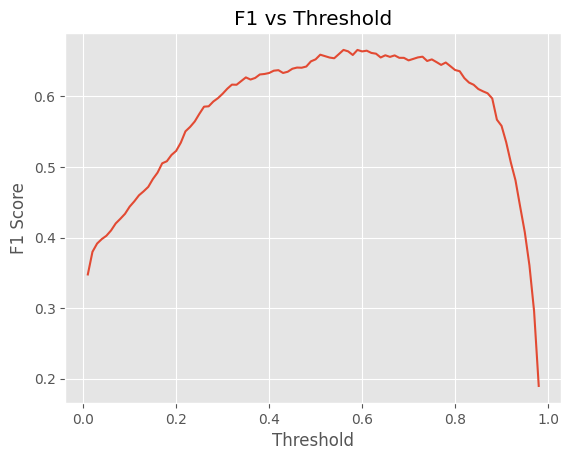

In [502]:
import matplotlib.pyplot as plt

f1_scores = []

for t in thresholds:
    y_pred = (y_val_proba >= t).astype(int)
    f1_scores.append(f1_score(y_val, y_pred))

plt.figure()
plt.plot(thresholds, f1_scores)
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 vs Threshold")
plt.show()

### FINAL STEP — Lock Threshold & Evaluate ONCE on Test

In [503]:
chosen_threshold = best_f1_threshold
# OR
#chosen_threshold = best_precision_threshold

### EVALUATE ON TEST
⚠️ Only do this once.

In [504]:
y_test_proba = best_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= chosen_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, average_precision_score

print("Test PR-AUC:", average_precision_score(y_test, y_test_proba))
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Test PR-AUC: 0.7324165560694929

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.96      0.89      0.92      1564
           1       0.58      0.79      0.67       286

    accuracy                           0.88      1850
   macro avg       0.77      0.84      0.80      1850
weighted avg       0.90      0.88      0.88      1850


Confusion Matrix:
[[1397  167]
 [  60  226]]


# OTHER

### 1. Feature Importance (SHAP)

**Feature Importance Analysis**

**Use** `SHAP`

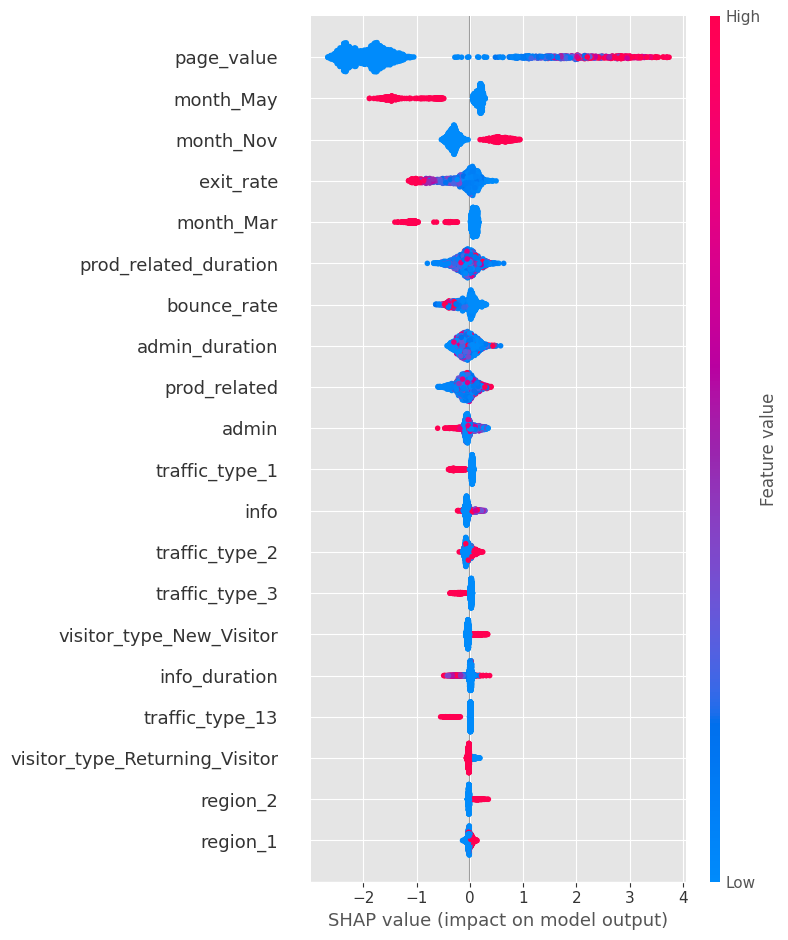

In [505]:
import shap

X_train = X_train.astype(float)
X_test = X_test.astype(float)

explainer = shap.TreeExplainer(model) # Create SHAP explainer
shap_values = explainer.shap_values(X_test) # Calculate SHAP values for the test set
shap.summary_plot(shap_values, X_test) # Plot SHAP summary plot

**Feature Selection**
Use `feature_importances_`

                           feature  importance
8                       page_value    0.206452
18                       month_Nov    0.058714
16                       month_Mar    0.048160
17                       month_May    0.045688
20                       month_Sep    0.030064
55                  traffic_type_5    0.028026
7                        exit_rate    0.024228
19                       month_Oct    0.023058
73  visitor_type_Returning_Visitor    0.022342
9                      special_day    0.020175


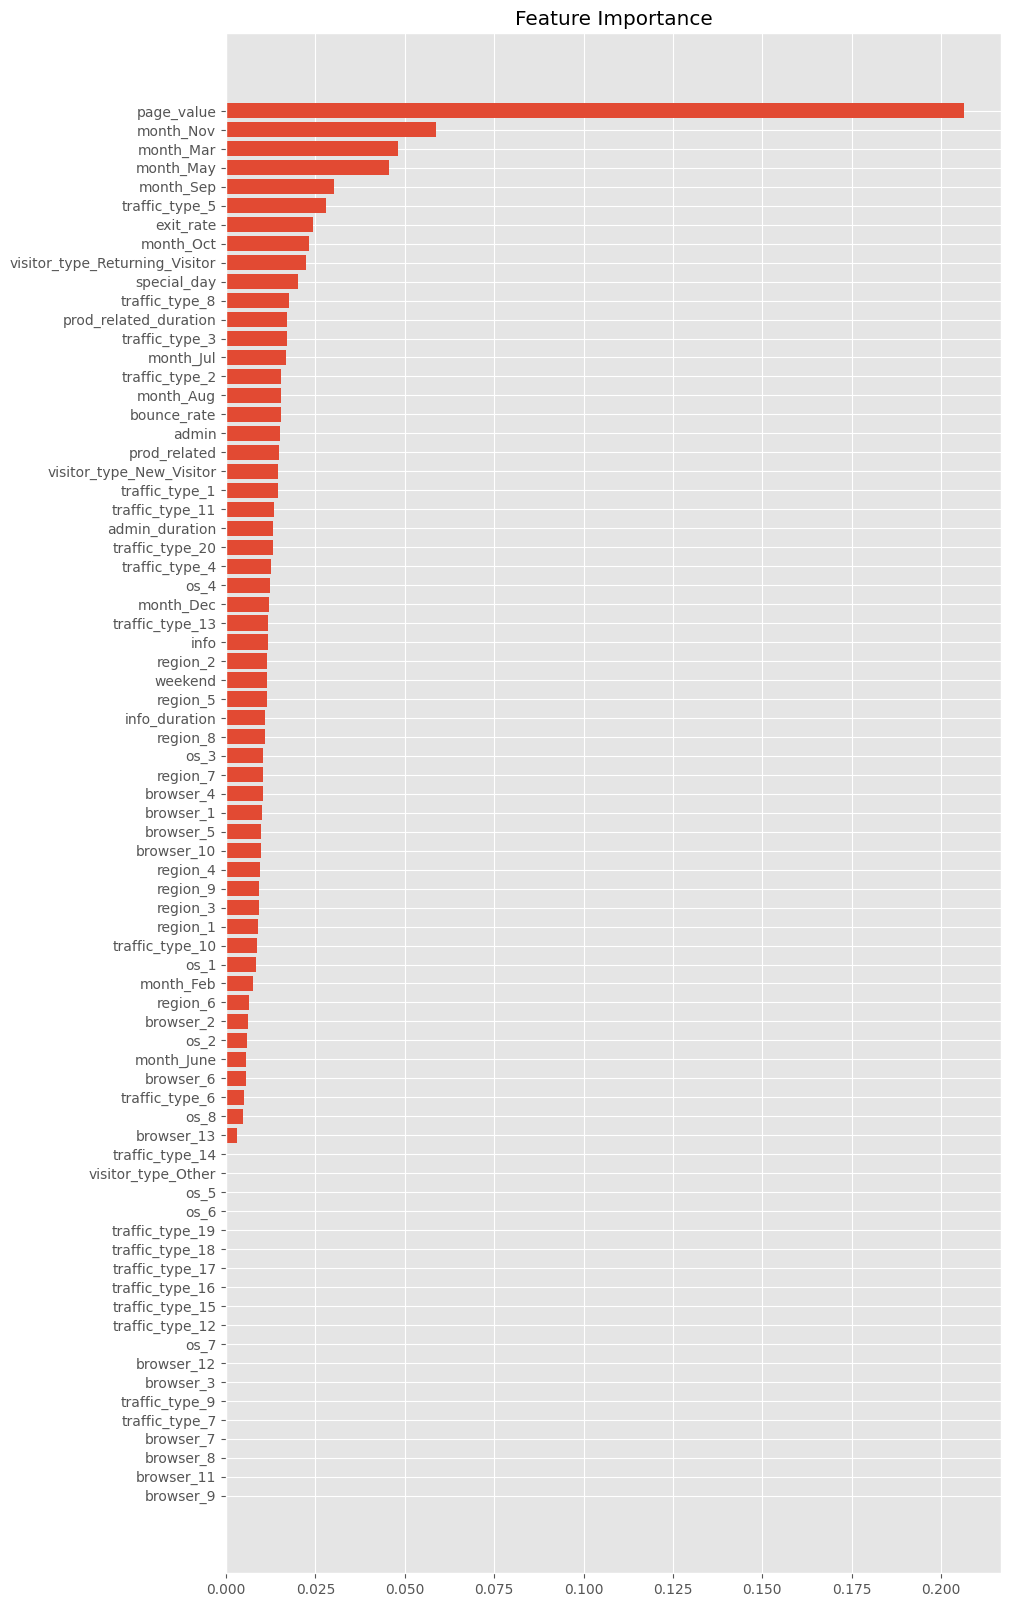

In [506]:
# Get importance
importances = model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
})

# Sort descending
feat_imp = feat_imp.sort_values(by="importance", ascending=False)

# print top 10 features
print(feat_imp.head(10))


# PLOT FEATURE IMPORTANCE
plt.figure(figsize=(10,20))
plt.barh(feat_imp["feature"], feat_imp["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

### 2. Decision Threshold Optimization

The most impactful next step is usually: Threshold optimization (because business decisions depend on it)

## Final test evaluation

In [507]:
# Predict on test
y_test_proba = best_model.predict_proba(X_test)[:, 1]

# Apply chosen threshold
chosen_threshold = best_f1_threshold  # or best_prec_threshold

y_test_pred = (y_test_proba >= chosen_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, average_precision_score

print("Test PR-AUC:", average_precision_score(y_test, y_test_proba))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred))

Test PR-AUC: 0.7324165560694929

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.96      0.89      0.92      1564
           1       0.58      0.79      0.67       286

    accuracy                           0.88      1850
   macro avg       0.77      0.84      0.80      1850
weighted avg       0.90      0.88      0.88      1850


Confusion Matrix (Test):
[[1397  167]
 [  60  226]]


## **Check over/under-fitting**

**Method 1: Compare Train vs Test AUC (more reliable than accuracy)**
- **Good generalization**  Small difference → model generalizes well.
- **OVERFITTING:** 
    - Large gap → model memorized training data. 
    - Rule of Thumb → If(Train − Test > 5–7%) probably overfitting.
- **UNDERFITTING:** Both low → model too simple.

In [508]:
from sklearn.metrics import roc_auc_score

# Predicted probabilities
y_train_proba = model.predict_proba(X_train)[:, 1]
y_test_proba = model.predict_proba(X_test)[:, 1]

# AUC scores
train_auc = roc_auc_score(y_train, y_train_proba)
test_auc = roc_auc_score(y_test, y_test_proba)

print(f"Train ROC AUC: {train_auc:.4f}")
print(f"Test ROC AUC:  {test_auc:.4f}")
print(f"Difference: {train_auc - test_auc:.4f}")

Train ROC AUC: 0.9726
Test ROC AUC:  0.9294
Difference: 0.0432


**Method 2: CROSS VALIDATION (CV Score)**

If I deploy this model, how stable and reliable will it be on new data?
- If CV score ≈ test score → good.
- If CV score much lower than train → overfitting.

In [509]:
from sklearn.model_selection import StratifiedKFold, cross_validate, RepeatedStratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

# Stratified K-Fold for classification
# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)

# Cross-validation with train + validation scores
cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    return_train_score=True
)

# Extract AUC scores
train_auc = cv_results["train_score"]
val_auc = cv_results["test_score"]

print("Train AUC per fold:", np.round(train_auc, 4))
print("Validation AUC per fold:", np.round(val_auc, 4))

print("\nMean Train AUC:", round(train_auc.mean(), 4))
print("Mean Validation AUC:", round(val_auc.mean(), 4))
print("Validation AUC Std:", round(val_auc.std(), 4))

ValueError: 
All the 10 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\sboub\AppData\Roaming\Python\Python311\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\sboub\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "C:\Users\sboub\AppData\Roaming\Python\Python311\site-packages\xgboost\sklearn.py", line 1806, in fit
    self._Booster = train(
                    ^^^^^^
  File "C:\Users\sboub\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "C:\Users\sboub\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py", line 201, in train
    if cb_container.after_iteration(bst, i, dtrain, evals):
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sboub\AppData\Roaming\Python\Python311\site-packages\xgboost\callback.py", line 268, in after_iteration
    ret = any(c.after_iteration(model, epoch, self.history) for c in self.callbacks)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sboub\AppData\Roaming\Python\Python311\site-packages\xgboost\callback.py", line 268, in <genexpr>
    ret = any(c.after_iteration(model, epoch, self.history) for c in self.callbacks)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sboub\AppData\Roaming\Python\Python311\site-packages\xgboost\callback.py", line 460, in after_iteration
    raise ValueError(msg)
ValueError: Must have at least 1 validation dataset for early stopping.
